<div class="alert alert-info" role="alert" style="padding:20px; margin-bottom:16px;">
  <div style="text-align:center;">
    <h1 style="margin:0;">Exploratory Data Analysis</h1>
    <div style="font-size:18px; margin-top:4px;">Amazing International Airlines Inc.</div>
    <div style="font-size:18px; margin-top:4px;">Clustering - Merge all perspectives</div>
    <hr style="margin:12px auto; width:220px;">
    <div style="font-size:14px; color:#6c757d;">Group 92 • Notebook • 2025/2026</div>
  </div>
</div>


This Project was done by:


Student Name    -   Mehmet Karaca;
student id      -   20250344;
contact email   -   20250344@novaims.unl.pt

Student Name    -   Duarte Gomes;
student id      -   20250017;
contact email   -   20250017@novaims.unl.pt

Student Name    -   Esra Salhi
student id      -   20250537
contact email   -   20250537@novaims.unl.pt

## Table of Contents



Add some contents here



# 1 Introduction <a id="introduction"></a>


## 1.1. Importing Libraries <a id="importing-libraries"></a>


In [1]:
# --- Standard Imports
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib
import math
import matplotlib as mpl
from cycler import cycler
import geopandas as gpd
from matplotlib.lines import Line2D
from sklearn.impute import KNNImputer
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.base import clone
from scipy.cluster.hierarchy import dendrogram, linkage



In [2]:
import warnings

# Suppress FutureWarnings (covers the pandas 3.0 CoW warnings)
warnings.simplefilter(action='ignore', category=FutureWarning)

## 1.2. Loading and Reading Data <a id="loading-and-reading-data"></a>

In [3]:
# directory with raw CSV files
data_dir = Path("../data/cleanAndFeatureEngineered")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")


Found CSV files: ['DM_AIAI_FlightsDB_Cleaned_Featured.csv', 'DM_AIAI_CustomerDB_Cleaned_Featured.csv']


In [4]:
# specify the files we want to load

customers_file = data_dir / "DM_AIAI_CustomerDB_Cleaned_Featured.csv"
flights_file   = data_dir / "DM_AIAI_FlightsDB_Cleaned_Featured.csv"

# load them with pandas
customers = pd.read_csv(customers_file)
flights   = pd.read_csv(flights_file)

print("Customers shape:", customers.shape)
print("Flights shape:", flights.shape)

Customers shape: (16375, 46)
Flights shape: (596664, 11)


## 1.3. Brief Preliminary Analysis <a id="brief-preliminary-analysis"></a>

In [5]:
customers.columns

Index(['Loyalty#', 'First Name', 'Last Name', 'Customer Name', 'Country',
       'City', 'Latitude', 'Longitude', 'Postal code', 'Income',
       'EnrollmentDateOpening', 'CancellationDate', 'Customer Lifetime Value',
       'IsActive', 'CustomerTenureDays', 'total_flights',
       'total_flights_with_companions', 'total_distance',
       'total_points_accumulated', 'total_points_redeemed',
       'total_cost_redeemed', 'average_distance_per_flight',
       'points_redemption_ratio', 'companion_flight_ratio',
       'LoyaltyStatus_Nova', 'LoyaltyStatus_Star', 'EnrollmentType_Standard',
       'Gender_male', 'Education_College', 'Education_Doctor',
       'Education_High School or Below', 'Education_Master',
       'Marital Status_Married', 'Marital Status_Single',
       'Province or State_British Columbia', 'Province or State_Manitoba',
       'Province or State_New Brunswick', 'Province or State_Newfoundland',
       'Province or State_Nova Scotia', 'Province or State_Ontario',
     

In [6]:
flights.columns

Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed', 'Season'],
      dtype='object')

In [7]:
customers.describe(include='number')

,Loyalty#,Latitude,Longitude,Income,Customer Lifetime Value,IsActive,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,...,Province or State_New Brunswick,Province or State_Newfoundland,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban
count,16375.000000,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,16375.000000,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,...,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000
mean,549432.932641,-3.888350e-15,2.681621e-16,-1.388542e-17,8.331249e-17,0.874931,-1.238839e-16,9.633007e-17,-1.598992e-16,-1.863683e-16,...,0.037924,0.015084,0.032122,0.322870,0.004031,0.196153,0.023878,0.006473,0.339053,0.326168
std,258720.547621,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,0.330807,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,...,0.191018,0.121891,0.176330,0.467588,0.063360,0.397098,0.152673,0.080198,0.473402,0.468824
min,100018.000000,-1.266925e+00,-1.942818e+00,-1.243243e+00,-8.893668e-01,0.000000,-1.489489e+00,-2.348401e+00,-1.532043e+00,-1.786988e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,326276.000000,-8.900536e-01,-1.276641e+00,-1.243243e+00,-5.851120e-01,1.000000,-9.714138e-01,-5.664426e-01,-8.118356e-01,-8.402688e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,550434.000000,-3.285937e-01,5.599171e-01,-1.188661e-01,-3.217508e-01,1.000000,-9.716237e-02,1.911105e-01,4.341034e-02,2.687935e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,771330.000000,6.375646e-01,7.751104e-01,8.125391e-01,1.395840e-01,1.000000,8.769265e-01,7.854892e-01,7.186045e-01,7.650067e-01,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,999986.000000,4.096615e+00,1.758859e+00,2.051974e+00,1.101364e+01,1.000000,1.837524e+00,2.644027e+00,3.824498e+00,2.605733e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
# Show me the variance of Customer Lifetime value in this dataset

customers['Customer Lifetime Value'].describe

<bound method NDFrame.describe of 0        -0.605614
1        -0.605545
2        -0.605524
3        -0.605524
4        -0.605080
           ...    
16370     7.874405
16371     8.759826
16372     9.683862
16373    11.013635
16374    11.013635
Name: Customer Lifetime Value, Length: 16375, dtype: float64>

# 2. Best Clustering for each perspective <a class="anchor" id="data-validity-checks"></a>

The best Clustering methods for each perspective was found in the previous notebooks. This methods will be applied again to put a label for the dataset customer. All entries will get 3 labels (One from each method)

In [9]:
# Define feature categories from previous analysis

value_based_features = [
    'Customer Lifetime Value',
    'Income',
    'total_points_accumulated',
    'total_cost_redeemed',
]


behavioral_features = [
    'total_flights',
    'total_flights_with_companions',
    'average_distance_per_flight',
    'total_distance',
    'CustomerTenureDays',
]


### Clustering Strategy by Perspective

We have selected the optimal clustering algorithms for each customer data perspective based on evaluation metrics (Silhouette, Inertia) and data distribution.
We first tried merging 3 perspectives, but we got bad results, that is why we will do 2 perspectives here. 

| **Perspective** | **Selected Algorithm** | **Configuration / Notes** |
| :--- | :--- | :--- |
| **Value Based** | **K-means ++** |  |
| **Behavioral** | **K-means++** |  |

In [10]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. R2 Score (Angepasst für Clustering)
# Misst, wie viel Streuung durch die Cluster erklärt wird (1.0 = perfekt getrennt)
def calculate_clustering_r2(X, labels):
    # Sicherstellen, dass X ein Numpy Array ist
    data = X.values if hasattr(X, 'values') else X
    
    # Globaler Schwerpunkt (Centroid) und totale Varianz (SST)
    global_mean = np.mean(data, axis=0)
    sst = np.sum((data - global_mean) ** 2)
    
    # Varianz innerhalb der Cluster (SSW)
    ssw = 0
    unique_labels = np.unique(labels)
    
    for label in unique_labels:
        cluster_points = data[labels == label]
        cluster_mean = np.mean(cluster_points, axis=0)
        ssw += np.sum((cluster_points - cluster_mean) ** 2)
        
    return 1 - (ssw / sst)

# 2. Silhouette Score Wrapper
def get_silhouette_score(X, labels):
    # Prüfung: Silhouette braucht mindestens 2 Cluster
    if len(np.unique(labels)) < 2:
        return np.nan
    return silhouette_score(X, labels)

# 3. Davies-Bouldin Index Wrapper
def get_davies_bouldin_index(X, labels):
    # Prüfung: Braucht ebenfalls min. 2 Cluster
    if len(np.unique(labels)) < 2:
        return np.nan
    return davies_bouldin_score(X, labels)


# Cell 3: Helper functions from Labs 09-12

def get_ss(df, feats):
    """
    Calculate the sum of squares (SS) for the given DataFrame.
    The sum of squares is computed as the sum of the variances of each column
    multiplied by the number of non-NA/null observations minus one.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame for which the sum of squares is to be calculated.
    feats (list of str): A list of feature column names to be used in the calculation.
    
    Returns:
    float: The sum of squares of the DataFrame.
    """
    df_ = df[feats]
    ss = np.sum(df_.var() * (df_.count() - 1))
    return ss


def get_ssb(df, feats, label_col):
    """
    Calculate the between-group sum of squares (SSB) for the given DataFrame.
    The between-group sum of squares is computed as the sum of the squared differences
    between the mean of each group and the overall mean, weighted by the number of observations
    in each group.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column in the DataFrame that contains the group labels.
    
    Returns:
    float: The between-group sum of squares of the DataFrame.
    """
    ssb_i = 0
    for i in np.unique(df[label_col]):
        df_ = df.loc[:, feats]
        X_ = df_.values
        X_k = df_.loc[df[label_col] == i].values
        
        ssb_i += (X_k.shape[0] * (np.square(X_k.mean(axis=0) - X_.mean(axis=0))))
    
    ssb = np.sum(ssb_i)
    return ssb


def get_ssw(df, feats, label_col):
    """
    Calculate the sum of squared within-cluster distances (SSW) for a given DataFrame.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing cluster labels.
    
    Returns:
    float: The sum of squared within-cluster distances (SSW).
    """
    feats_label = feats + [label_col]
    df_k = df[feats_label].groupby(by=label_col).apply(
        lambda col: get_ss(col, feats),
        include_groups=False
    )
    return df_k.sum()


def get_rsq(df, feats, label_col):
    """
    Calculate the R-squared value for a given DataFrame and features.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame containing the data.
    feats (list): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing the labels or cluster assignments.
    
    Returns:
    float: The R-squared value, representing the proportion of variance explained by the clustering.
    """
    df_sst_ = get_ss(df, feats)  # get total sum of squares
    df_ssw_ = get_ssw(df, feats, label_col)  # get ss within
    df_ssb_ = df_sst_ - df_ssw_  # get ss between
    # r2 = ssb/sst
    return (df_ssb_ / df_sst_)


def get_r2_scores(df, feats, clusterer, min_k=1, max_k=9):
    """
    Loop over different values of k. To be used with sklearn clusterers.
    """
    r2_clust = {}
    for n in range(min_k, max_k):
        clust = clone(clusterer).set_params(n_clusters=n)
        labels = clust.fit_predict(df)
        df_concat = pd.concat([df,
                               pd.Series(labels, name='labels', index=df.index)], axis=1)
        r2_clust[n] = get_rsq(df_concat, feats, 'labels')
    return r2_clust

## 2.1 Value Based 

In [11]:
# Create a copy of customers for value-based clustering with the selected features
value_based_df = customers.copy()
value_based_df = customers[value_based_features]
value_based_df.head()

,Customer Lifetime Value,Income,total_points_accumulated,total_cost_redeemed
0,-0.605614,1.068659,1.338311,0.576033
1,-0.605545,-1.243243,0.843514,1.584071
2,-0.605524,-1.243243,-0.317841,-0.369294
3,-0.605524,-1.243243,0.592203,0.896561
4,-0.605080,1.981146,0.488700,-0.987124


In [12]:
# --- Manual Selection & Saving (K-Means) ---

# 1. INPUT CHOSEN K HERE
selected_k = 5 # <--- Update this based on Elbow/Gradient plots!

print(f"Finalizing K-Means++ with K={selected_k}...")

# 2. Fit the Final Model
X_final = value_based_df.values 

kmeans_final = KMeans(n_clusters=selected_k, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_final)

# 4. Final Confirmation & Stats
sil_score = silhouette_score(X_final, kmeans_labels)
print(f"Done. 'cluster_kmeans' column added.")
print(f"Final Inertia: {kmeans_final.inertia_:.2f}")
print(f"Final Silhouette Score: {sil_score:.4f}")

Finalizing K-Means++ with K=5...
Done. 'cluster_kmeans' column added.
Final Inertia: 26203.68
Final Silhouette Score: 0.2802


In [13]:
"""import numpy as np
from sklearn.cluster import MeanShift
from sklearn.metrics import silhouette_score

selected_quantile = 0.15
bandwidth = 0.6710

# Apply Meanshift to the value_based_df
ms_value_based = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms_labels_value_based = ms_value_based.fit_predict(value_based_df)


n_clusters = len(np.unique(ms_labels_value_based))
print(f"Number of clusters found: {n_clusters}")

# Calculate metrics with helper functions
print(f"R2 Score: {calculate_clustering_r2(value_based_df, ms_labels_value_based):.4f}")
print(f"Silhouette: {get_silhouette_score(value_based_df, ms_labels_value_based):.4f}")
print(f"Davies-Bouldin: {get_davies_bouldin_index(value_based_df, ms_labels_value_based):.4f}")"""

'import numpy as np\nfrom sklearn.cluster import MeanShift\nfrom sklearn.metrics import silhouette_score\n\nselected_quantile = 0.15\nbandwidth = 0.6710\n\n# Apply Meanshift to the value_based_df\nms_value_based = MeanShift(bandwidth=bandwidth, bin_seeding=True)\nms_labels_value_based = ms_value_based.fit_predict(value_based_df)\n\n\nn_clusters = len(np.unique(ms_labels_value_based))\nprint(f"Number of clusters found: {n_clusters}")\n\n# Calculate metrics with helper functions\nprint(f"R2 Score: {calculate_clustering_r2(value_based_df, ms_labels_value_based):.4f}")\nprint(f"Silhouette: {get_silhouette_score(value_based_df, ms_labels_value_based):.4f}")\nprint(f"Davies-Bouldin: {get_davies_bouldin_index(value_based_df, ms_labels_value_based):.4f}")'

In [14]:
# Save the labels as integer to the customers DataFrame as value_based_cluster_labels
customers['value_based_cluster_labels'] = kmeans_labels.astype(int)

In [15]:
# Show head of customers
customers.head()

,Loyalty#,First Name,Last Name,Customer Name,Country,City,Latitude,Longitude,Postal code,Income,...,Province or State_Newfoundland,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban,value_based_cluster_labels
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Toronto,-1.064828,0.559917,M2Z 4K1,1.068659,...,0,0,1,0,0,0,0,0,1,1
1,549612,Dayle,Menez,Dayle Menez,Canada,Edmonton,1.926313,-0.973351,T3G 6Y6,-1.243243,...,0,0,0,0,0,0,0,0,0,3
2,429460,Necole,Hannon,Necole Hannon,Canada,Vancouver,0.637565,-1.406246,V6E 3D9,-1.243243,...,0,0,0,0,0,0,0,0,1,2
3,608370,Queen,Hagee,Queen Hagee,Canada,Toronto,-1.064828,0.559917,P1W 1K4,-1.243243,...,0,0,1,0,0,0,0,1,0,2
4,530508,Claire,Latting,Claire Latting,Canada,Hull,-0.527905,0.724889,J8Y 3Z5,1.981146,...,0,0,0,0,1,0,0,1,0,1


## 2.2 Behavioral

In [16]:
# Create a copy of customers for value-based clustering with the selected features
behavioral_df = customers.copy()
behavioral_df = customers[behavioral_features]
behavioral_df.head()

,total_flights,total_flights_with_companions,average_distance_per_flight,total_distance,CustomerTenureDays
0,1.107125,0.853643,1.338112,1.338111,-0.072878
1,1.892954,-0.181654,0.843651,0.843650,-0.102559
2,-0.292522,0.133436,-0.317819,-0.317820,0.229333
3,0.555749,0.943669,0.592203,0.592202,1.403096
4,0.446770,1.123721,0.488742,0.488742,0.572018


In the previous notebook we dropped correlated columns, so we need to replicate it too.

In [17]:
# Delete the feature average_distance_per_flight
behavioral_df = behavioral_df.drop(columns=['average_distance_per_flight'])
behavioral_df.head()


# Delete them from behavioral_features list
behavioral_features.remove('average_distance_per_flight')

In [18]:
len(behavioral_df.columns)

4

In [19]:
"""from sklearn.cluster import MeanShift
from sklearn.metrics import silhouette_score

selected_quantile = 0.15 
bandwidth = 0.7133

# Apply Meanshift to the behavioral_df
ms_behavioral = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms_labels_behavioral = ms_behavioral.fit_predict(behavioral_df)



# Print the scores of the clustering
n_clusters = len(np.unique(ms_labels_behavioral))
print(f"Number of clusters found: {n_clusters}")

# Calculate metrics with helper functions
print(f"R2 Score: {calculate_clustering_r2(behavioral_df, ms_labels_behavioral):.4f}")
print(f"Silhouette: {get_silhouette_score(behavioral_df, ms_labels_behavioral):.4f}")
print(f"Davies-Bouldin: {get_davies_bouldin_index(behavioral_df, ms_labels_behavioral):.4f}")"""

'from sklearn.cluster import MeanShift\nfrom sklearn.metrics import silhouette_score\n\nselected_quantile = 0.15 \nbandwidth = 0.7133\n\n# Apply Meanshift to the behavioral_df\nms_behavioral = MeanShift(bandwidth=bandwidth, bin_seeding=True)\nms_labels_behavioral = ms_behavioral.fit_predict(behavioral_df)\n\n\n\n# Print the scores of the clustering\nn_clusters = len(np.unique(ms_labels_behavioral))\nprint(f"Number of clusters found: {n_clusters}")\n\n# Calculate metrics with helper functions\nprint(f"R2 Score: {calculate_clustering_r2(behavioral_df, ms_labels_behavioral):.4f}")\nprint(f"Silhouette: {get_silhouette_score(behavioral_df, ms_labels_behavioral):.4f}")\nprint(f"Davies-Bouldin: {get_davies_bouldin_index(behavioral_df, ms_labels_behavioral):.4f}")'

In [20]:
# --- Manual Selection & Saving (K-Means) ---

# 1. INPUT CHOSEN K HERE
selected_k = 6 # <--- Update this based on Elbow/Gradient plots!

print(f"Finalizing K-Means++ with K={selected_k}...")

# 2. Fit the Final Model
X_final = value_based_df.values 

kmeans_final_behavioral = KMeans(n_clusters=selected_k, init='k-means++', n_init=10, random_state=42)
kmeans_labels_behavioral = kmeans_final_behavioral.fit_predict(X_final)

# 4. Final Confirmation & Stats
sil_score = silhouette_score(X_final, kmeans_labels_behavioral)
print(f"Done. 'cluster_kmeans' column added.")
print(f"Final Inertia: {kmeans_final_behavioral.inertia_:.2f}")
print(f"Final Silhouette Score: {sil_score:.4f}")

Finalizing K-Means++ with K=6...
Done. 'cluster_kmeans' column added.
Final Inertia: 23153.87
Final Silhouette Score: 0.2730


In [21]:
# Save the labels to the customers DataFrame as behavioral_cluster_labels
customers['behavioral_cluster_labels'] = kmeans_labels_behavioral.astype(int)

# 3. Merge all Clustering Perspectives to one

In [22]:
# Create a value and behavioral feature list 
behaivoral_value_based_features = value_based_features + behavioral_features

In [23]:
# unique labels in each clustering multiplied together
unique_value_based = customers['value_based_cluster_labels'].nunique()
unique_behavioral = customers['behavioral_cluster_labels'].nunique()

unique_value_based * unique_behavioral

30

Apply Hierarchical Clustering on cluster centroids

In [24]:
#  Calculate centroids for each combination (only metric features)

df_centroids = customers.groupby(['value_based_cluster_labels', 'behavioral_cluster_labels'])[behaivoral_value_based_features].mean()
df_centroids.head()

Customer Lifetime Value  \
value_based_cluster_labels behavioral_cluster_labels                            
0                          0                                         1.703939   
                           1                                         1.867552   
                           3                                         2.980093   
                           4                                         1.617243   
                           5                                         1.953184   

                                                        Income  \
value_based_cluster_labels behavioral_cluster_labels             
0                          0                          1.023984   
                           1                         -1.075108   
                           3                         -0.004172   
                           4                         -1.243243   
                           5                          1.194867   

                                                      total_points_accumulated  \
value_based_cluster_labels behavioral_cluster_labels                             
0                          0                                          1.277171   
                           1                                         -1.379827   
                           3                                          0.072076   
                           4                                          0.646719   
                           5                                         -1.416159   

                                                      total_cost_redeemed  \
value_based_cluster_labels behavioral_cluster_labels                        
0                          0                                     0.290344   
                           1                                    -0.764365   
                           3                                    -0.006024   
                           4                                    -0.232256   
                           5                                    -0.723012   

                                                      total_flights  \
value_based_cluster_labels behavioral_cluster_labels                  
0                          0                               0.964863   
                           1                              -1.183685   
                           3                               0.078264   
                           4                               0.007908   
                           5                              -0.942212   

                                                      total_flights_with_companions  \
value_based_cluster_labels behavioral_cluster_labels                                  
0                          0                                               0.459780   
                           1                                              -1.093166   
                           3                                               0.063063   
                           4                                               0.268475   
                           5                                              -1.126926   

                                                      total_distance  \
value_based_cluster_labels behavioral_cluster_labels                   
0                          0                                1.277043   
                           1                               -1.379829   
                           3                                0.072078   
                           4                                0.646666   
                           5                               -1.416173   

                                                      CustomerTenureDays  
value_based_cluster_labels behavioral_cluster_labels                      
0                          0                                   -0.286718  
                           1                                   -0.8843

In [25]:
print(f"\nCentroids shape: {df_centroids.shape}")


Centroids shape: (18, 8)


#### We will assume ward linkage 

#### But need to decide the number of final clusters 

In [26]:
# Fit hierarchical clustering with distance tracking
hclust = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    distance_threshold=0,
    n_clusters=None
)
hclust_labels = hclust.fit_predict(df_centroids)

# Build linkage matrix for dendrogram
# (Adapted from scikit-learn documentation)
counts = np.zeros(hclust.children_.shape[0])
n_samples = len(hclust.labels_)

for i, merge in enumerate(hclust.children_):
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            current_count += 1  # Leaf node
        else:
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count

linkage_matrix = np.column_stack([
    hclust.children_,
    hclust.distances_,
    counts
]).astype(float)

print("Linkage matrix ready for dendrogram!")

Linkage matrix ready for dendrogram!


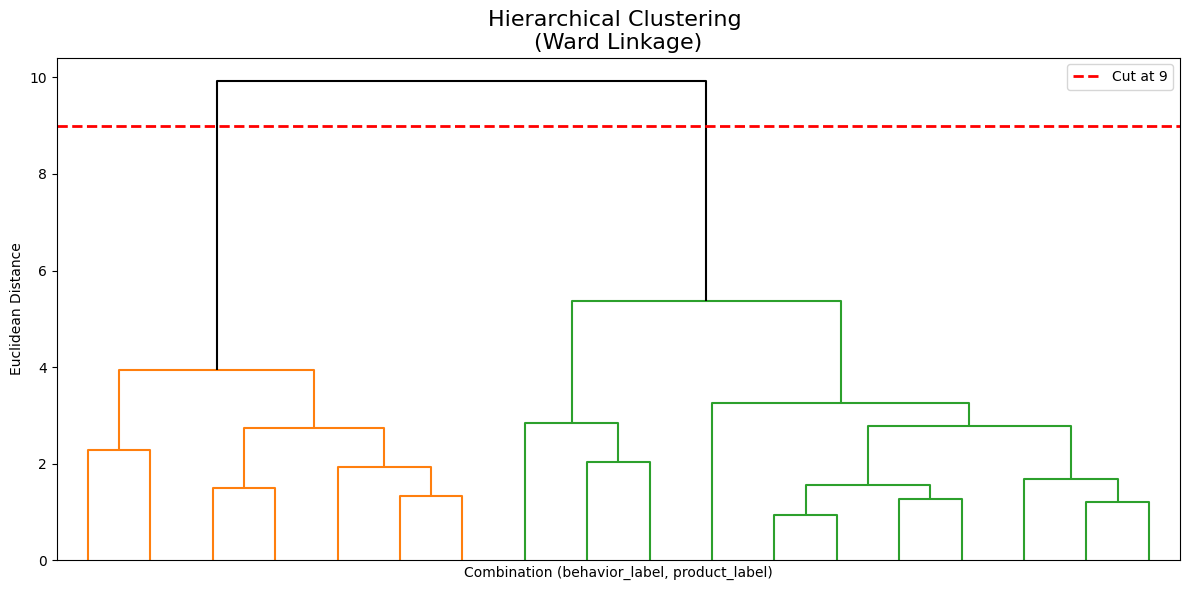

In [27]:
# Cell 18: Plot dendrogram with cutting options
fig = plt.figure(figsize=(12, 6))

# Potential cutting heights to consider
y_threshold = 9  # Can adjust this!

dendrogram(
    linkage_matrix,
    labels=df_centroids.index,
    color_threshold=y_threshold,
    above_threshold_color='k',
    no_labels=True  # Hide the labels on the x-axis
)

plt.axhline(y=y_threshold, color='r', linestyle='--', linewidth=2, label=f'Cut at {y_threshold}')

plt.title(f'Hierarchical Clustering \n(Ward Linkage)', fontsize=16)
plt.xlabel('Combination (behavior_label, product_label)')
plt.ylabel('Euclidean Distance')
plt.legend()
# plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
n_final_clusters = 4

hclust_final = AgglomerativeClustering(
    linkage='ward',
    n_clusters=n_final_clusters
)

hclust_final_labels = hclust_final.fit_predict(df_centroids)
hclust_final_labels

array([2, 3, 2, 2, 3, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1])

In [43]:
# Add to centroids dataframe
df_centroids['merged_labels'] = hclust_final_labels
df_centroids

Customer Lifetime Value  \
value_based_cluster_labels behavioral_cluster_labels                            
0                          0                                         1.703939   
                           1                                         1.867552   
                           3                                         2.980093   
                           4                                         1.617243   
                           5                                         1.953184   
1                          0                                        -0.193388   
                           4                                        -0.250815   
                           5                                        -0.181363   
2                          0                                        -0.492178   
                           1                                        -0.283211   
                           2                                        -0.850715   
                           4                                        -0.245503   
3                          0                                        -0.255951   
                           2                                        -0.186799   
                           4                                        -0.235149   
4                          1                                        -0.191813   
                           4                                        -0.427827   
                           5                                        -0.166164   

                                                        Income  \
value_based_cluster_labels behavioral_cluster_labels             
0                          0                          1.023984   
                           1                         -1.075108   
                           3                         -0.004172   
                           4                         -1.243243   
                           5                          1.194867   
1                          0                          1.092506   
                           4                          0.236553   
                           5                          1.322445   
2                          0                          0.106405   
                           1                         -1.140142   
                           2                         -1.243243   
                           4                         -0.761085   
3                          0                          0.853659   
                           2                         -0.271538   
                           4                         -0.538701   
4                          1                         -0.706261   
                           4                          0.017297   
                           5                          0.906281   

                                                      total_points_accumulated  \
value_based_cluster_labels behavioral_cluster_labels                             
0                          0                                          1.277171   
                           1                                         -1.379827   
                           3                                          0.072076   
                           4                                          0.646719   
                           5                                         -1.416159   
1                          0                                          0.577495   
                           4                                          0.447205   
                           5                                         -0.594279   
2                          0                                          0.944205   
                           1                                         -0.630818   
                           2                                         -0.253730   
                           4                  

In [44]:
cluster_mapper = df_centroids['merged_labels'].to_dict()
cluster_mapper  

{(0, 0): 2,
 (0, 1): 3,
 (0, 3): 2,
 (0, 4): 2,
 (0, 5): 3,
 (1, 0): 0,
 (1, 4): 0,
 (1, 5): 1,
 (2, 0): 0,
 (2, 1): 1,
 (2, 2): 0,
 (2, 4): 0,
 (3, 0): 0,
 (3, 2): 0,
 (3, 4): 0,
 (4, 1): 1,
 (4, 4): 1,
 (4, 5): 1}

In [45]:
# Cell 21: Map merged labels back to all customers

customers['merged_labels'] = customers.apply(
    lambda row: cluster_mapper[(row['value_based_cluster_labels'], row['behavioral_cluster_labels'])],
    axis=1
)
customers

,Loyalty#,First Name,Last Name,Customer Name,Country,City,Latitude,Longitude,Postal code,Income,...,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban,value_based_cluster_labels,behavioral_cluster_labels,merged_labels
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Toronto,-1.064828,0.559917,M2Z 4K1,1.068659,...,1,0,0,0,0,0,1,1,0,0
1,549612,Dayle,Menez,Dayle Menez,Canada,Edmonton,1.926313,-0.973351,T3G 6Y6,-1.243243,...,0,0,0,0,0,0,0,3,2,0
2,429460,Necole,Hannon,Necole Hannon,Canada,Vancouver,0.637565,-1.406246,V6E 3D9,-1.243243,...,0,0,0,0,0,0,1,2,4,0
3,608370,Queen,Hagee,Queen Hagee,Canada,Toronto,-1.064828,0.559917,P1W 1K4,-1.243243,...,1,0,0,0,0,1,0,2,4,0
4,530508,Claire,Latting,Claire Latting,Canada,Hull,-0.527905,0.724889,J8Y 3Z5,1.981146,...,0,0,1,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16370,823768,Mandy,Sammarco,Mandy Sammarco,Canada,Vancouver,0.637565,-1.406246,V6E 3Z3,-1.243243,...,0,0,0,0,0,0,0,0,3,2
16371,680886,Jamee,Ahlm,Jamee Ahlm,Canada,Regina,0.989105,-0.574521,S1J 3C5,1.337732,...,0,0,0,1,0,0,0,0,3,2
16372,776187,Janina,Lumb,Janina Lumb,Canada,Vancouver,0.637565,-1.406246,V5R 1W3,-1.243243,...,0,0,0,0,0,0,1,0,3,2
16373,615459,Dannie,Paplow,Dannie Paplow,Canada,Montreal,-0.505842,0.821365,H2Y 4R4,0.699920,...,0,0,1,0,0,0,1,0,3,2


In [46]:
print(customers['merged_labels'].value_counts().sort_index())

merged_labels
0    10570
1     4732
2     1038
3       35
Name: count, dtype: int64


In [47]:
# Quick distinctiveness check (R²)
r2_merged = get_rsq(customers, behaivoral_value_based_features, 'merged_labels')
print(f"\nMerged clustering R²: {r2_merged:.4f}")


Merged clustering R²: 0.4518


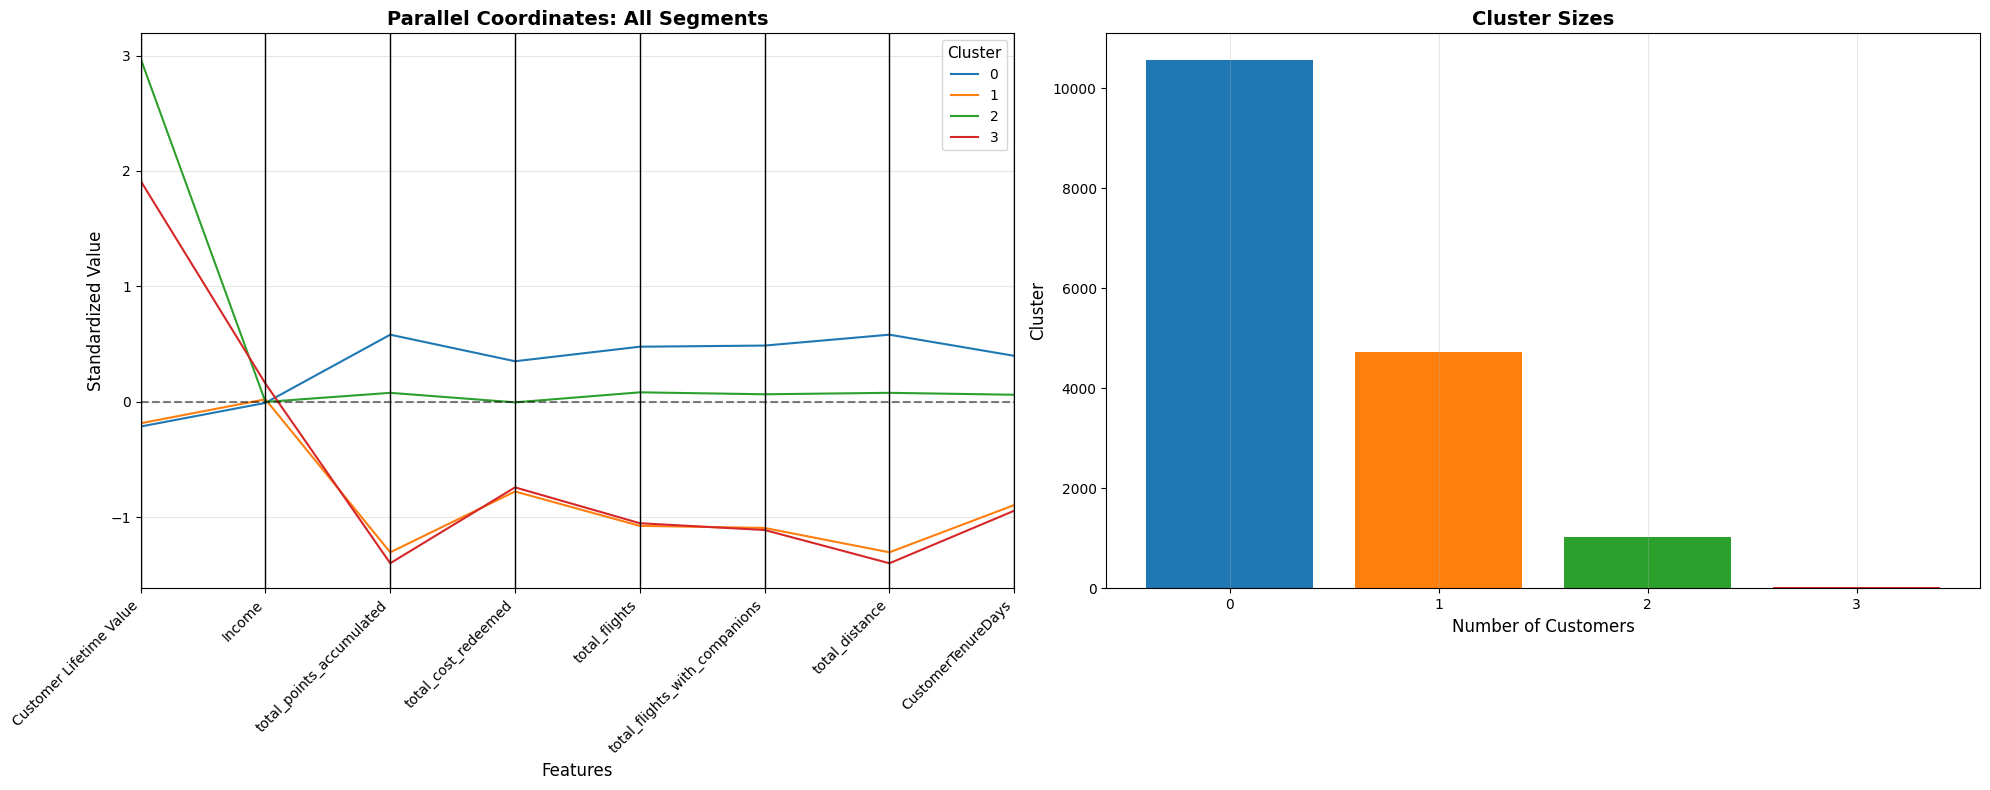

In [48]:
# Create combined features list for behavioral and value based (removing duplicates)
combined_features = list(dict.fromkeys(value_based_features + behavioral_features))

# Filter for all segments
all_segments = customers[combined_features].copy()

# Add merged labels to all_segments
all_segments['merged_labels'] = customers['merged_labels']

unique_labels = sorted(all_segments['merged_labels'].unique())
df_all_centroids = all_segments.groupby('merged_labels')[combined_features].mean()

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# LEFT PLOT: Parallel coordinates for all clusters
plt.sca(ax1)
pd.plotting.parallel_coordinates(
    df_all_centroids.reset_index(),
    'merged_labels',
    color=sns.color_palette('tab10', n_colors=len(unique_labels)),
    ax=ax1
)
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
ax1.set_title('Parallel Coordinates: All Segments', fontsize=14, fontweight='bold')
ax1.set_ylabel('Standardized Value', fontsize=12)
ax1.set_xlabel('Features', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax1.legend(title='Cluster', loc='best', title_fontsize=11)
ax1.grid(True, alpha=0.3)

# RIGHT PLOT: Cluster sizes (ordered by cluster number)
cluster_sizes = all_segments['merged_labels'].value_counts().sort_index()
colors = sns.color_palette('tab10', n_colors=len(unique_labels))

ax2.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=colors)
ax2.set_xlabel('Number of Customers', fontsize=12)
ax2.set_ylabel('Cluster', fontsize=12)
ax2.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

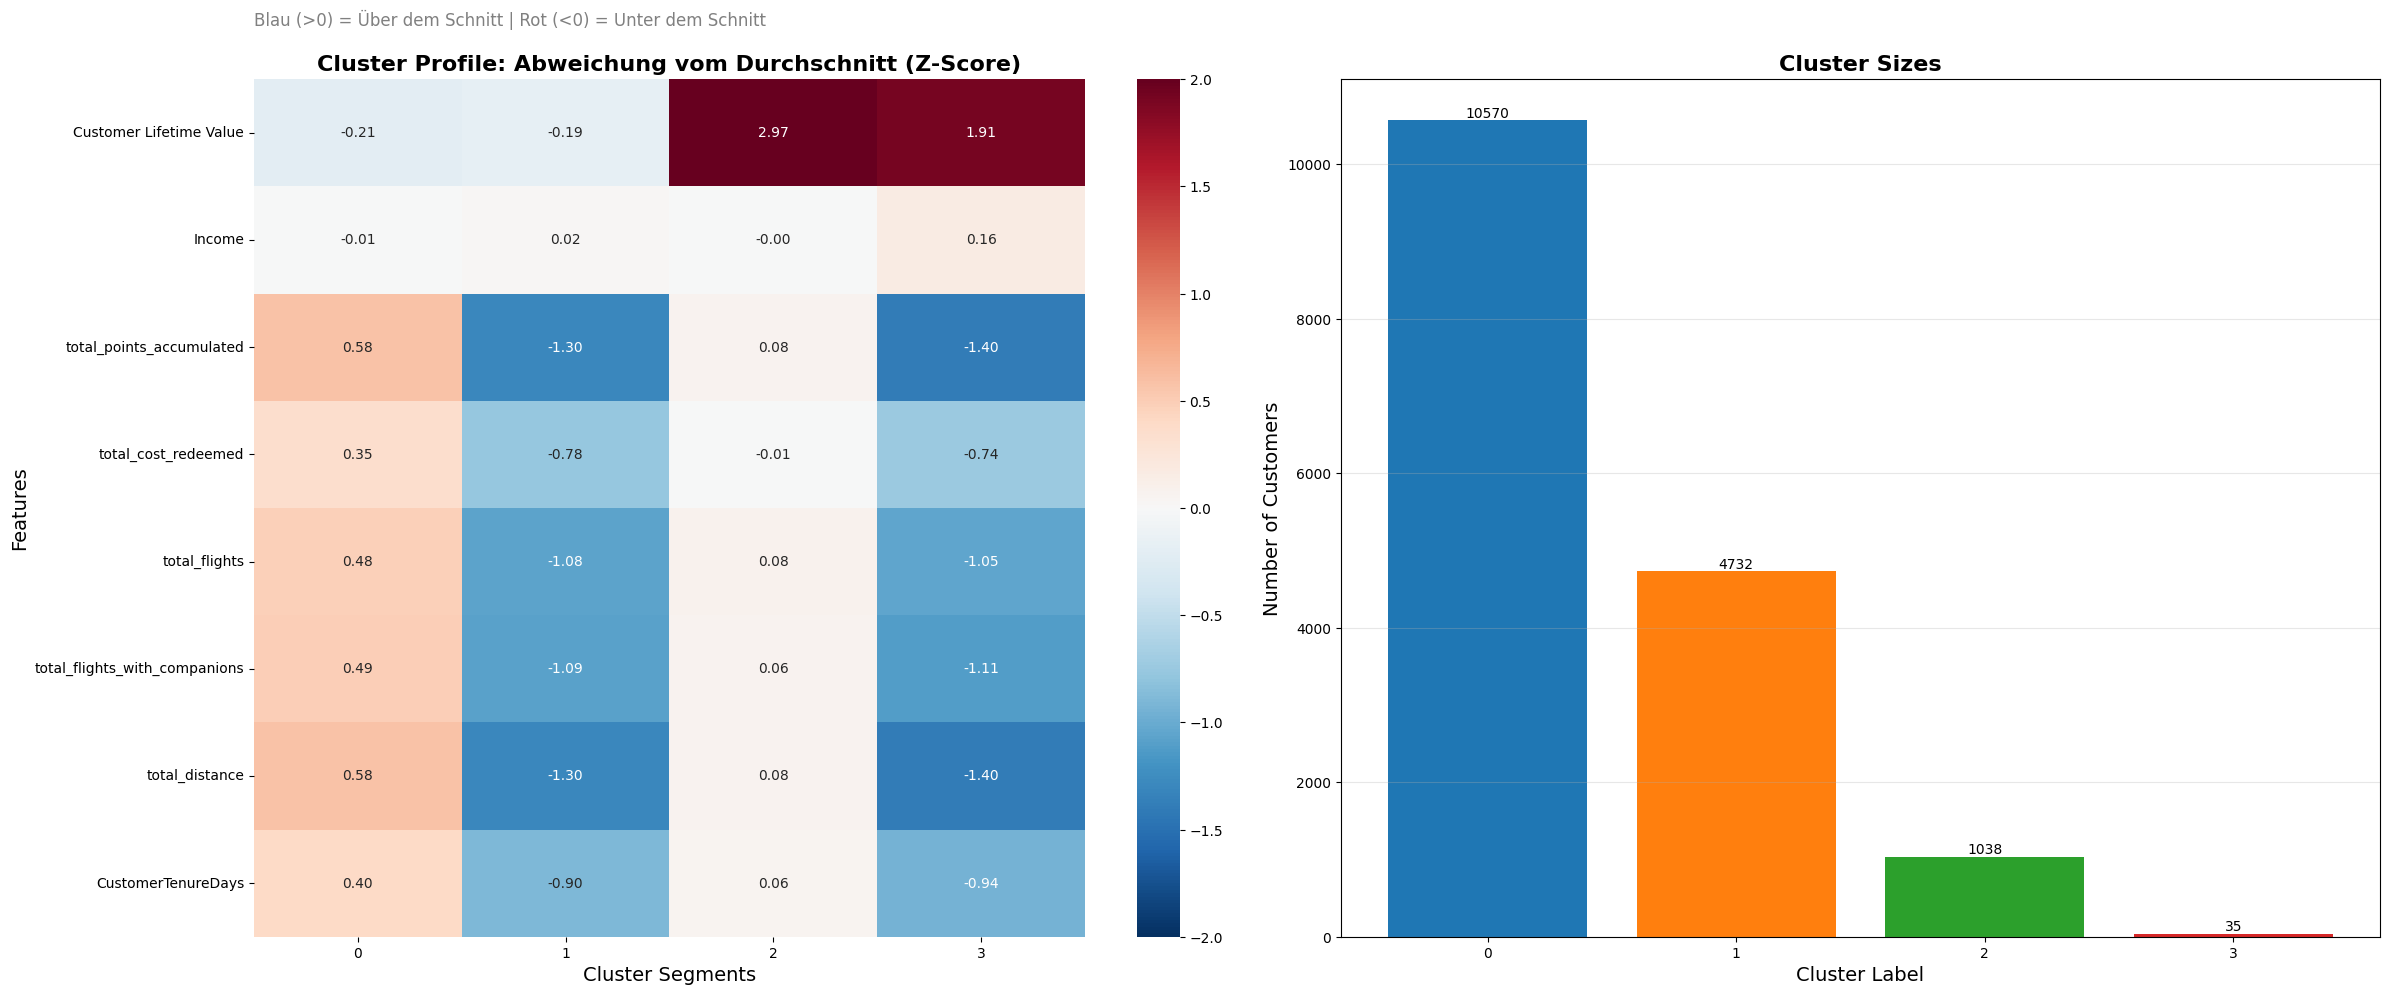

In [49]:
# ===========================================================
# VISUALISIERUNG FÜR STANDARD SCALER DATEN (Z-Scores)
# ===========================================================

# 1. Features auswählen
combined_features = list(dict.fromkeys(value_based_features + behavioral_features))

# 2. Centroids berechnen (Das sind jetzt Z-Scores!)
# 'customers' enthält jetzt deine Standard-Scaled Werte
df_z_scores = customers.groupby('merged_labels')[combined_features].mean().T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# --- PLOT 1: HEATMAP DER ABWEICHUNGEN (Z-SCORES) ---
sns.heatmap(
    df_z_scores,
    annot=True,            # Zeigt die Z-Scores (z.B. +1.2 oder -0.5)
    fmt=".2f",
    cmap='RdBu_r',         # Rot-Weiß-Blau (Perfekt für Abweichungen vom Durchschnitt)
    center=0,              # Weiß ist genau der Durchschnitt (0)
    vmax=2, vmin=-2,       # Begrenzung für besseren Kontrast (Ausreißer ignorieren)
    ax=ax1
)

ax1.set_title('Cluster Profile: Abweichung vom Durchschnitt (Z-Score)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Features', fontsize=14)
ax1.set_xlabel('Cluster Segments', fontsize=14)
# Erklärung für den Leser hinzufügen
ax1.text(0, -0.5, 'Blau (>0) = Über dem Schnitt | Rot (<0) = Unter dem Schnitt', fontsize=12, color='gray')


# --- PLOT 2: CLUSTER GRÖSSEN ---
cluster_sizes = customers['merged_labels'].value_counts().sort_index()
colors = sns.color_palette('tab10', n_colors=len(cluster_sizes))

bars = ax2.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=colors)

# Zahlen über die Balken schreiben
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

ax2.set_xlabel('Cluster Label', fontsize=14)
ax2.set_ylabel('Number of Customers', fontsize=14)
ax2.set_title('Cluster Sizes', fontsize=16, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
# Show only the customer with merged label 5 

customers[customers['merged_labels'] == 3].transpose()

,3618,3705,3709,3710,3722,3730,3754,3758,3762,3763,...,9321,9322,9334,15954,16005,16086,16113,16114,16130,16142
Loyalty#,428765,711565,721494,118376,784710,667398,465476,521043,324049,968842,...,678991,895821,921624,836720,231992,920197,601997,860528,348350,128405
First Name,Eulah,Madaline,Corinna,Sue,Laurene,Drema,Ariel,Shaun,Chan,Shandi,...,Robbin,Ailene,Anamaria,Lidia,Adalberto,Loura,Genevieve,Ulysses,Kathy,Jolene
Last Name,Melchiori,Carpen,Mcclure,Wittry,Welters,Heagney,Desch,Prevo,Northrup,Cardeiro,...,Moulds,Poorte,Schrauger,Coad,Mccuiston,Rafalko,Yagin,Manfredini,Musi,Morissette
Customer Name,Eulah Melchiori,Madaline Carpen,Corinna Mcclure,Sue Wittry,Laurene Welters,Drema Heagney,Ariel Desch,Shaun Prevo,Chan Northrup,Shandi Cardeiro,...,Robbin Moulds,Ailene Poorte,Anamaria Schrauger,Lidia Coad,Adalberto Mccuiston,Loura Rafalko,Genevieve Yagin,Ulysses Manfredini,Kathy Musi,Jolene Morissette
Country,Canada,Canada,Canada,Canada,Canada,Canada,Canada,Canada,Canada,Canada,...,Canada,Canada,Canada,Canada,Canada,Canada,Canada,Canada,Canada,Canada
City,Toronto,Whistler,Vancouver,Kelowna,Toronto,Toronto,Edmonton,Vancouver,Toronto,Toronto,...,Vancouver,Montreal,Winnipeg,Toronto,Dawson Creek,Vancouver,Montreal,Whistler,Vancouver,Montreal
Latitude,-1.064828,0.889647,0.637565,0.820587,-1.064828,-1.064828,1.926313,0.637565,-1.064828,-1.064828,...,0.637565,-0.505842,0.82276,-1.064828,2.596213,0.637565,-0.505842,0.889647,0.637565,-0.505842
Longitude,0.559917,-1.398902,-1.406246,-1.243301,0.559917,0.559917,-0.973351,-1.406246,0.559917,0.559917,...,-1.406246,0.821365,-0.238244,0.559917,-1.276641,-1.406246,0.821365,-1.398902,-1.406246,0.821365
Postal code,M8Y 4K8,V6T 1Y8,V1E 4R6,V09 2E9,M8Y 4K8,P5S 6R4,T9G 1W3,V5R 1W3,P1J 8T7,M8Y 4K8,...,V1E 4R6,H2Y 2W2,R2C 0M5,M2Z 4K1,U5I 4F1,V5R 1W3,H2Y 4R4,V6T 1Y8,V6E 3D9,H2Y 4R4
Income,-1.243243,1.814179,1.816947,-1.243243,-1.243243,-1.243243,0.439483,1.304806,-1.243243,0.960061,...,0.922917,0.689604,1.343796,1.13685,0.748105,-1.243243,1.411229,1.081018,1.273397,1.382061


In [51]:
# Show all customers with negative customer tenure days
customers[customers['CustomerTenureDays'] < 0]

,Loyalty#,First Name,Last Name,Customer Name,Country,City,Latitude,Longitude,Postal code,Income,...,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban,value_based_cluster_labels,behavioral_cluster_labels,merged_labels
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Toronto,-1.064828,0.559917,M2Z 4K1,1.068659,...,1,0,0,0,0,0,1,1,0,0
1,549612,Dayle,Menez,Dayle Menez,Canada,Edmonton,1.926313,-0.973351,T3G 6Y6,-1.243243,...,0,0,0,0,0,0,0,3,2,0
6,188893,Nakia,Cash,Nakia Cash,Canada,Trenton,-0.929379,0.641143,K8V 4B2,1.830856,...,1,0,0,0,0,1,0,1,0,0
8,866307,Dustin,Recine,Dustin Recine,Canada,Toronto,-1.064828,0.559917,M8Y 4K8,1.830856,...,1,0,0,0,0,1,0,1,0,0
10,144514,Belkis,Siurek,Belkis Siurek,Canada,Dawson Creek,2.596213,-1.276641,U5I 4F1,-0.445517,...,0,0,0,0,0,0,1,2,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16358,118864,Eartha,Pesso,Eartha Pesso,Canada,Toronto,-1.064828,0.559917,M2M 7K8,-1.243243,...,1,0,0,0,0,0,1,0,3,2
16359,632951,Devorah,Litzau,Devorah Litzau,Canada,Edmonton,1.926313,-0.973351,T9G 1W3,-1.243243,...,0,0,0,0,0,0,0,0,3,2
16368,672917,Tam,Whyte,Tam Whyte,Canada,Toronto,-1.064828,0.559917,M1R 4K3,0.777801,...,1,0,0,0,0,0,1,0,3,2
16373,615459,Dannie,Paplow,Dannie Paplow,Canada,Montreal,-0.505842,0.821365,H2Y 4R4,0.699920,...,0,0,1,0,0,0,1,0,3,2
